# **Variational AutoEncoders (VAE)**

In [28]:
import tensorflow as tf
import os
import random
import numpy as np

#verificando as GPUs disponíveis
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [29]:
#criando uma seed

SEED = 123456
os.environ['PYTHONHASHSEED']=str(SEED)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1' 
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [30]:
#importando o dataset, dividindo em treino e teste e verificando se está tudo no formato correto

from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

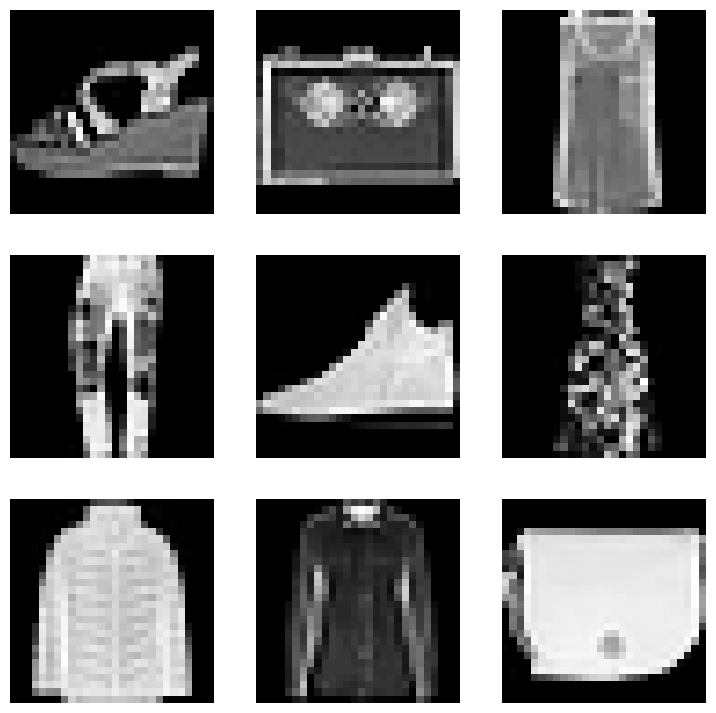

In [31]:
import numpy as np
from matplotlib import pyplot as plt

plt.figure(figsize=(9, 9))

#plotando 9 imagens do conjunto de treino
rndSamples = np.random.choice(60000, 9)

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[rndSamples[i]], cmap="Greys_r")
    plt.axis('off')

plt.show();

In [32]:
#unindo os dados de treino e teste em um só dataset
dataset = np.concatenate([x_train, x_test], axis=0)

#adicionando uma dimensão extra e normalizando 
dataset = np.expand_dims(dataset, -1).astype("float32") / 255

## Custom Sampling Layer ##

In [33]:
from tensorflow import keras
from tensorflow.keras import layers


#definindo uma camada para implementar a reparametrização
class SamplingLayer(layers.Layer):
  """Reparameterization Trick z = mu + sigma * epsilon"""

  def call(self, inputs):
    zMean, zLogVar = inputs
    batch = tf.shape(zMean)[0]
    dim = tf.shape(zMean)[1]
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
    return zMean + tf.exp(0.5 * zLogVar) * epsilon

## Encoder / Decoder ##

In [34]:
#definindo o encoder
def buildEncoder(latentDim, encoderInputs):

  #criando as camadas de convolução
  l1 = keras.models.Sequential([
    layers.Conv2D(128, 3, activation="relu", strides=2, padding="same"),
    layers.Conv2D(64, 3, activation="relu", strides=2, padding="same"),
    layers.Flatten(),
    layers.Dense(256, activation="relu")
  ])

  #passando as entradas para o bloco de convolução
  x = l1(encoderInputs)

  #camada para aprender a média em paralelo
  zMean = layers.Dense(latentDim, name="z_mean")(x)

  #camada para aprender a variância em paralelo
  zLogVar = layers.Dense(latentDim, name="z_log_var")(x)

  #utilizando a camada de reparametrização
  z = SamplingLayer()([zMean, zLogVar])

#retornando o modelo
  return keras.Model(encoderInputs, [zMean, zLogVar, z], name="encoder")


#construindo o encoder
encoderInputs = keras.Input(shape=(28, 28, 1))
encoder = buildEncoder(2, encoderInputs)
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 256)       │    878,144 │ input_layer_4[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        514 │ sequential_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        514 │ sequential_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_layer_1    │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (SamplingLayer)     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 879,172 (3.35 MB)

 Trainable params: 879,172 (3.35 MB)

 Non-trainable params: 0 (0.00 B)

And now we'll implement the decoder in a similar fashion. Note the use of Conv2DTranspose instead of Conv2D; we use the transpose convolution to generate images going from lower resolutions to higher ones. That's the real heart of this technique.

In [35]:
#definindo o decoder
def buildDecoder(latentInputs):

  #camadas de conv2d transpose
  l1 = keras.models.Sequential([
    layers.Dense(7*7*64, activation="relu", input_shape=(latentInputs.shape[1],)),
    layers.Reshape((7,7,64)),
    layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same"),
    layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same"),
    layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")
  ])

  #retornando o modelo
  return keras.Model(latentInputs, l1(latentInputs), name="decoder")

#construindo o modelo
latentInputs = keras.Input(shape=(2,))
decoder = buildDecoder(latentInputs)
decoder.summary()

/home/lucasarenhardt/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 28, 28, 1)      │       157,633 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,633 (615.75 KB)

 Trainable params: 157,633 (615.75 KB)

 Non-trainable params: 0 (0.00 B)

## Loss Functions ##

In [36]:
#calcula a loss de reconstrução entre os dados de entrada e saída
def reconstructionLoss(data, reconstructed):
  return tf.reduce_mean(
      tf.reduce_sum(
          keras.losses.binary_crossentropy(data, reconstructed),
          axis=(1, 2)
      )
  )

In [37]:
#calcula a diferença entre duas distribuições probabilísticas
def klDivergenceLoss(zMean, zLogVar):
  return tf.reduce_mean(
      tf.reduce_sum(
          -0.5 * (1 + zLogVar - tf.square(zMean) - tf.exp(zLogVar)),
          axis=1
      )
  )

In [38]:
#calculando a loss total
def calcTotalLoss(data, reconstructed, zMean, zLogVar):
  loss1 = reconstructionLoss(data, reconstructed)
  loss2 = klDivergenceLoss(zMean, zLogVar)
  klWeight = 3.0
  return  loss1, loss2, loss1 + klWeight * loss2

## Overriding train_step ##

In [39]:
#criando o modelo VAE
class VAE(keras.Model):
  def __init__(self, encoder, decoder, **kwargs):
    super(VAE, self).__init__(**kwargs)
    self.encoder = encoder
    self.decoder = decoder
    #observando a loss total
    self.totalLossTracker = keras.metrics.Mean(name="total_loss")
    self.ceLossTracker = keras.metrics.Mean(name="ce_loss")
    self.klLossTracker = keras.metrics.Mean(name="kl_loss")
    
  # This are all observable metrics 
  @property
  def metrics(self):
    return [
        self.totalLossTracker,
        self.ceLossTracker,
        self.klLossTracker
    ]

  #calculando loss, gradientes e pesos
  def train_step(self, data):
    # Gradient tape is a recording of all gradients for the trainable 
    # weights that need to be updated
    with tf.GradientTape() as tape:
        # forward path
        zMean, zLogVar, z = self.encoder(data)
        reconstruction = self.decoder(z)
        ceLoss, klLoss, totalLoss = calcTotalLoss(data, reconstruction, zMean, zLogVar)
    #backpropagation
    grads = tape.gradient(totalLoss, self.trainable_weights)
    self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

    #observando o loss
    self.totalLossTracker.update_state(totalLoss)
    self.ceLossTracker.update_state(ceLoss)
    self.klLossTracker.update_state(klLoss)

    #retornando o loss
    return {
        "total_loss": self.totalLossTracker.result(),
        "ce_loss": self.ceLossTracker.result(),
        "kl_loss": self.klLossTracker.result()
    }

## Train the VAE! ##

In [40]:
#realizando o treinamento
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001))
history = vae.fit(dataset, epochs=32, batch_size=128)

Epoch 1/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - ce_loss: 348.6098 - kl_loss: 2.8514 - total_loss: 357.1640
Epoch 2/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - ce_loss: 266.2080 - kl_loss: 4.5553 - total_loss: 279.8738
Epoch 3/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - ce_loss: 262.0791 - kl_loss: 4.6809 - total_loss: 276.1217
Epoch 4/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - ce_loss: 260.0485 - kl_loss: 4.7442 - total_loss: 274.2810
Epoch 5/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - ce_loss: 258.9155 - kl_loss: 4.7834 - total_loss: 273.2656
Epoch 6/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - ce_loss: 257.9581 - kl_loss: 4.8299 - total_loss: 272.4479
Epoch 7/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - ce_loss: 257.0635 - kl_loss: 4.8568 - total_loss: 271.6339
Epoch 8/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - ce_loss: 256.3661 - kl_loss: 4.8869 - total_loss: 271.0267
Epoch 9/32
547/547 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - ce_loss: 255.8364 - kl_loss: 4.9

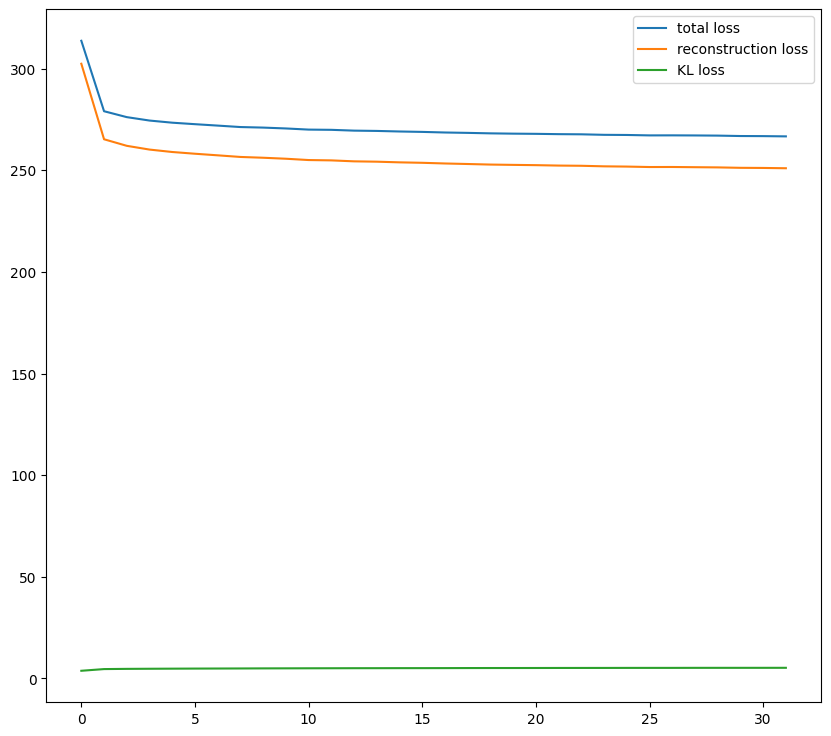

In [41]:
#visualizando as loss functions por época
plt.figure(figsize=(10, 9))
plt.plot(history.history.get('total_loss'), label="total loss")
plt.plot(history.history.get('ce_loss'), label="reconstruction loss")
plt.plot(history.history.get('kl_loss'), label="KL loss")
plt.legend();

Let's zoom into the KL loss so we can see it better:

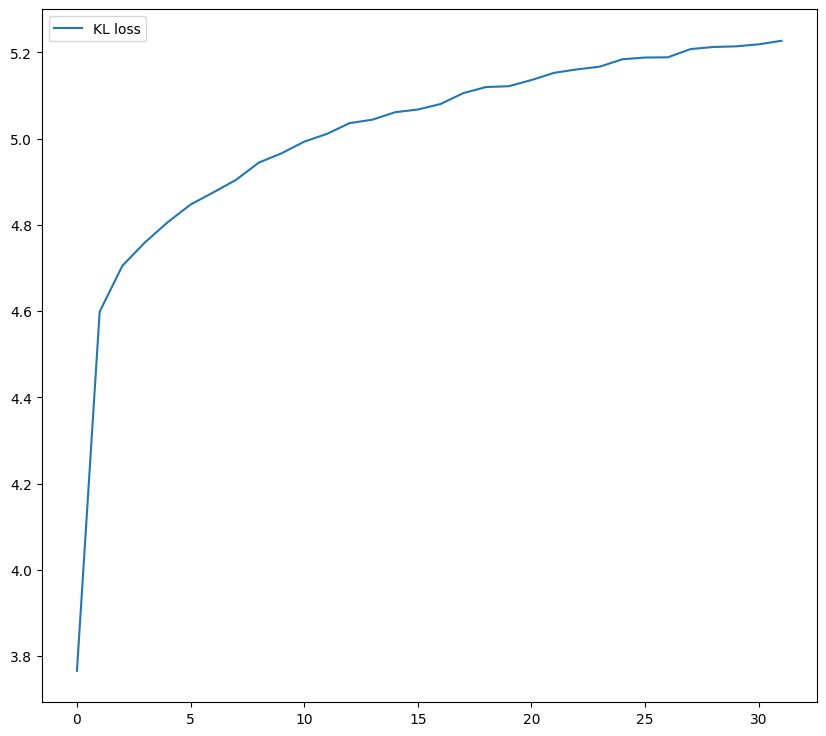

In [42]:
#visualizando o KL loss
plt.figure(figsize=(10, 9))
plt.plot(history.history.get('kl_loss'), label="KL loss")
plt.legend();

# Explore the results ##

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


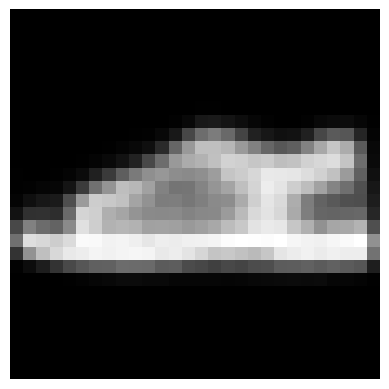

In [43]:
#gerando uma imagem
synth = vae.decoder.predict(np.array([[1, 2]]))
plt.axis('off')
plt.imshow(synth.reshape((28,28)), cmap="Greys_r");

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


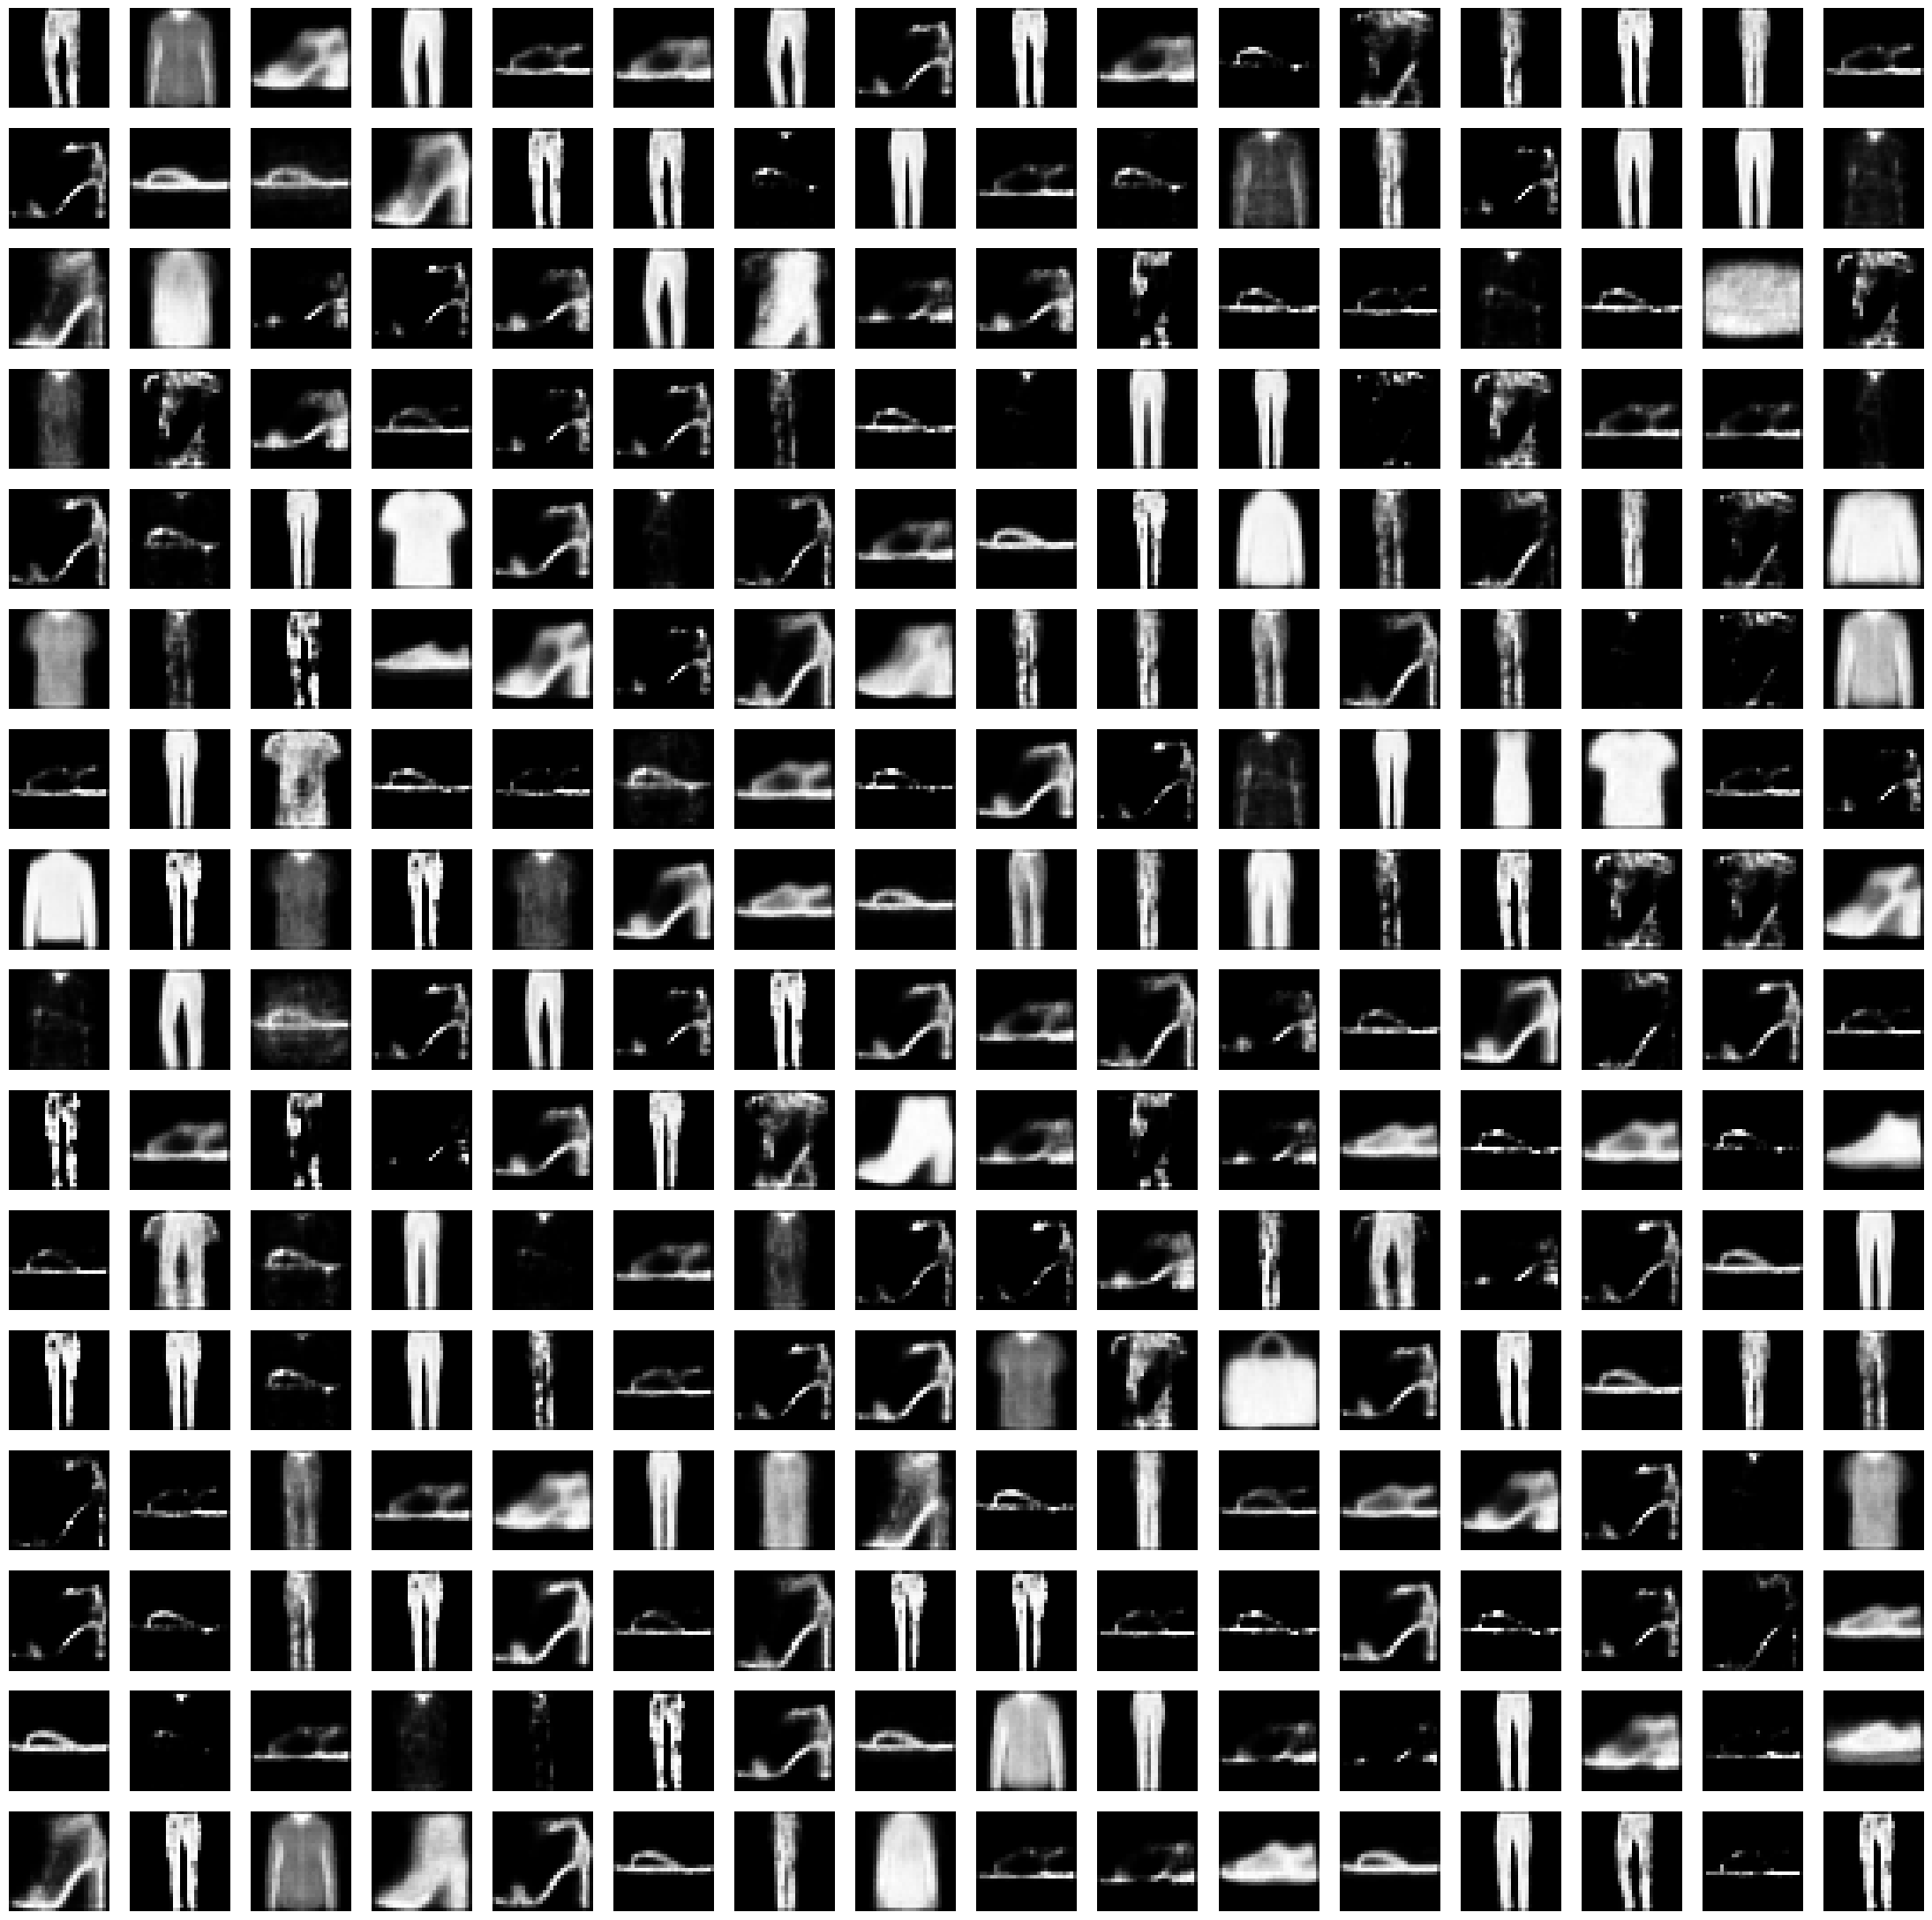

In [44]:
#gerando 256 imagens aleatóriamente
z = np.random.normal(loc=0, scale=4, size=(256,2))
synth = vae.decoder.predict(z)

plt.figure(figsize=(28,28))

for i in range(256):
    plt.subplot(16,16,i+1)
    plt.imshow(synth[i].reshape((28,28)), cmap="Greys_r")
    plt.axis('off')

plt.show();

In [45]:
#escolhendo uma imagem e com base nela, construindo uma similar

idx = 1280
batch = np.expand_dims(x_train[idx], axis=0)
batchOfImages = np.expand_dims(batch, axis=-1).astype("float32") / 255
print(batchOfImages.shape)

_, _, z = vae.encoder.predict(batchOfImages)


synth = vae.decoder.predict([z])

z

(1, 28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


array([[ 0.07232085, -1.371125  ]], dtype=float32)

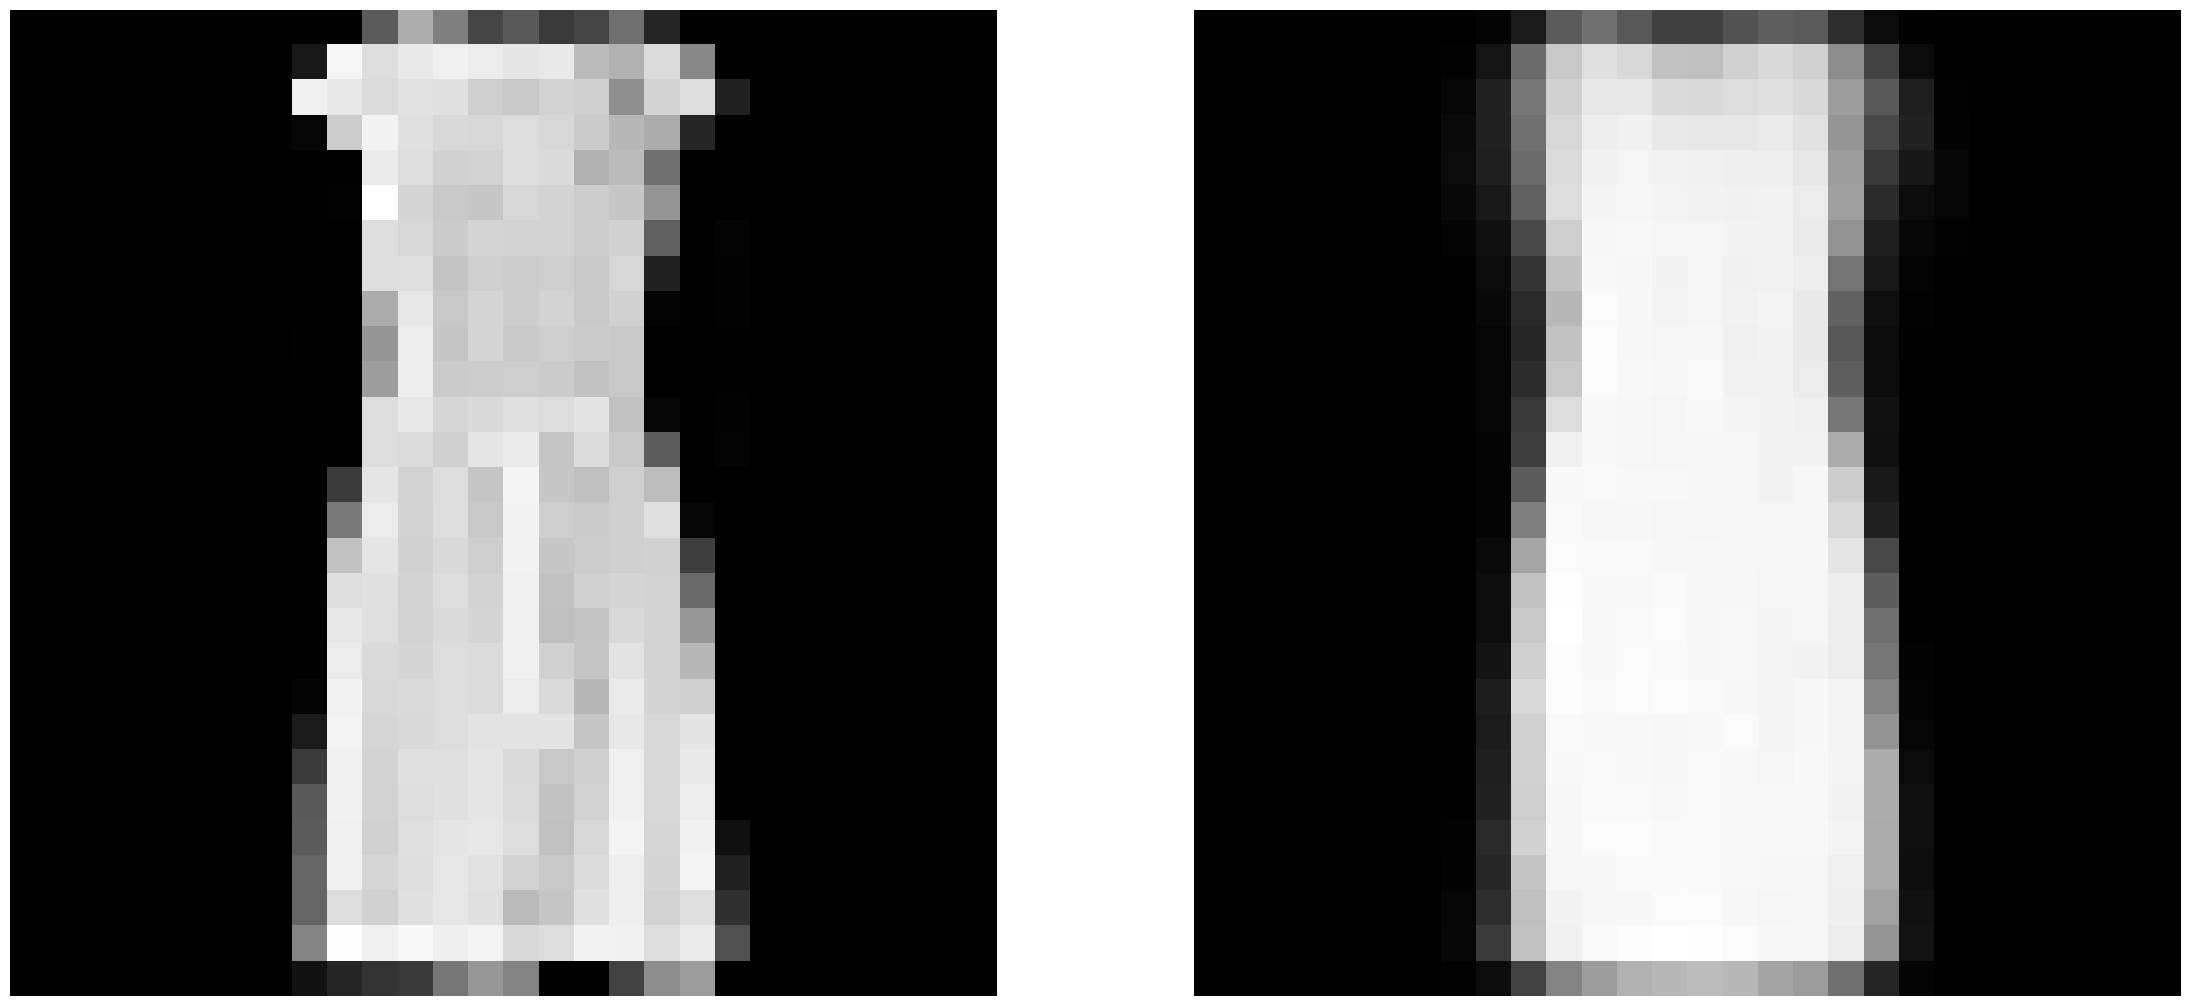

In [46]:
#plotando a imagem original e a reconstruída
plt.figure(figsize=(28, 28))

plt.subplot(1,2,1)
plt.axis('off')
plt.imshow(x_train[idx], cmap="Greys_r")


plt.subplot(1,2,2)
plt.axis('off')
plt.imshow(synth[0].reshape((28,28)), cmap="Greys_r")
plt.show();

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 2s 903us/step


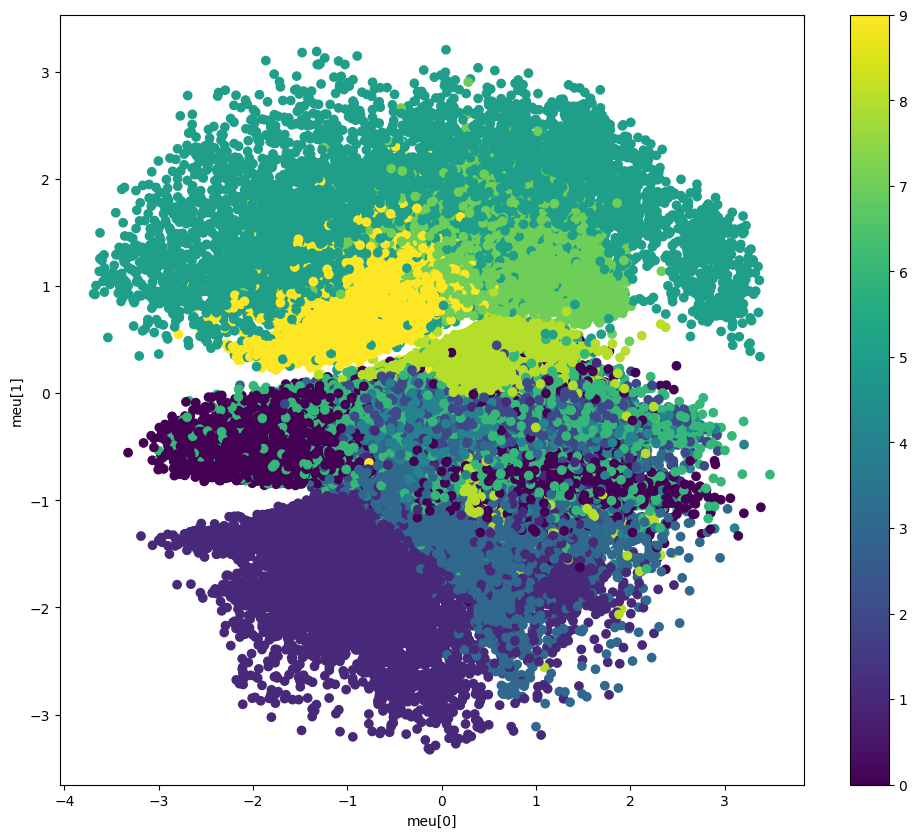

In [47]:
#entrando com o dataset inteiro no encoder e plotando as distribuições probabilísticas

labels = np.concatenate([y_train, y_test], axis=0)
meu, _, _ = vae.encoder.predict(dataset)
plt.figure(figsize=(12, 10))
plt.scatter(meu[:, 0], meu[:, 1], c=labels)
plt.colorbar()
plt.xlabel("meu[0]")
plt.ylabel("meu[1]")
plt.show();